<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/Assignment14rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
%pip install fairlearn
%pip install lime

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    false_negative_rate,
)
from sklearn.metrics import accuracy_score, precision_score

In [74]:
df = pd.read_csv("biased_salary_dataset.csv")

df.head()

,Employee_ID,Gender,Age,Experience_Years,Education_Level,City,Salary
0,1,Male,45,0,Master,Ramallah,7099
1,2,Male,40,2,PhD,Nablus,10056
2,3,Male,38,7,High School,Jenin,9540
3,4,Female,36,7,Master,Nablus,11502
4,5,Male,32,13,Master,Ramallah,17020


In [98]:
print(df['Gender'].value_counts()['Female'])
print(df['Gender'].value_counts()['Male'])

513
487


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       1000 non-null   int64 
 1   Gender            1000 non-null   object
 2   Age               1000 non-null   int64 
 3   Experience_Years  1000 non-null   int64 
 4   Education_Level   1000 non-null   object
 5   City              1000 non-null   object
 6   Salary            1000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 54.8+ KB


In [78]:
# Example: define high salary as above median
threshold = df["Salary"].median()
df["high_salary"] = (df["Salary"] > threshold).astype(int)

X = df[["Gender", "Age", "Experience_Years", "Education_Level", "City"]]
y = df["high_salary"]
A = df["Gender"]  # sensitive attribute

In [80]:
numeric_features = ["Age", "Experience_Years"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [82]:
adult = fetch_openml(data_id=1590, as_frame=True)
X_adult = adult.data
y_adult = (adult.target == ">50K").astype(int)
A_adult = X_adult["sex"]  # sensitive attribute

In [85]:
numeric_features_adult = selector(dtype_include=["int64", "float64"])(X_adult)
categorical_features_adult = selector(dtype_include=["object"])(X_adult)

numeric_transformer_adult = Pipeline(
    steps=[("scaler", StandardScaler())]
)
categorical_transformer_adult = OneHotEncoder(handle_unknown="ignore")

preprocess_adult = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_adult, numeric_features_adult),
        ("cat", categorical_transformer_adult, categorical_features_adult),
    ]
)

In [87]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42, stratify=y
)

log_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.965
Confusion matrix:
 [[98  2]
 [ 5 95]]
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       100
           1       0.98      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



In [90]:
metrics = {
    "accuracy": accuracy_score,
    "precision": precision_score,
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test,
)

print("Overall metrics:\n", mf.overall)
print("\nBy group:\n", mf.by_group)

Overall metrics:
 accuracy               0.965000
precision              0.979381
selection_rate         0.485000
false_positive_rate    0.020000
false_negative_rate    0.050000
dtype: float64

By group:
         accuracy  precision  selection_rate  false_positive_rate  \
Gender                                                             
Female  0.969072   0.976190        0.432990             0.018519   
Male    0.961165   0.981818        0.533981             0.021739   

        false_negative_rate  
Gender                       
Female             0.046512  
Male               0.052632  


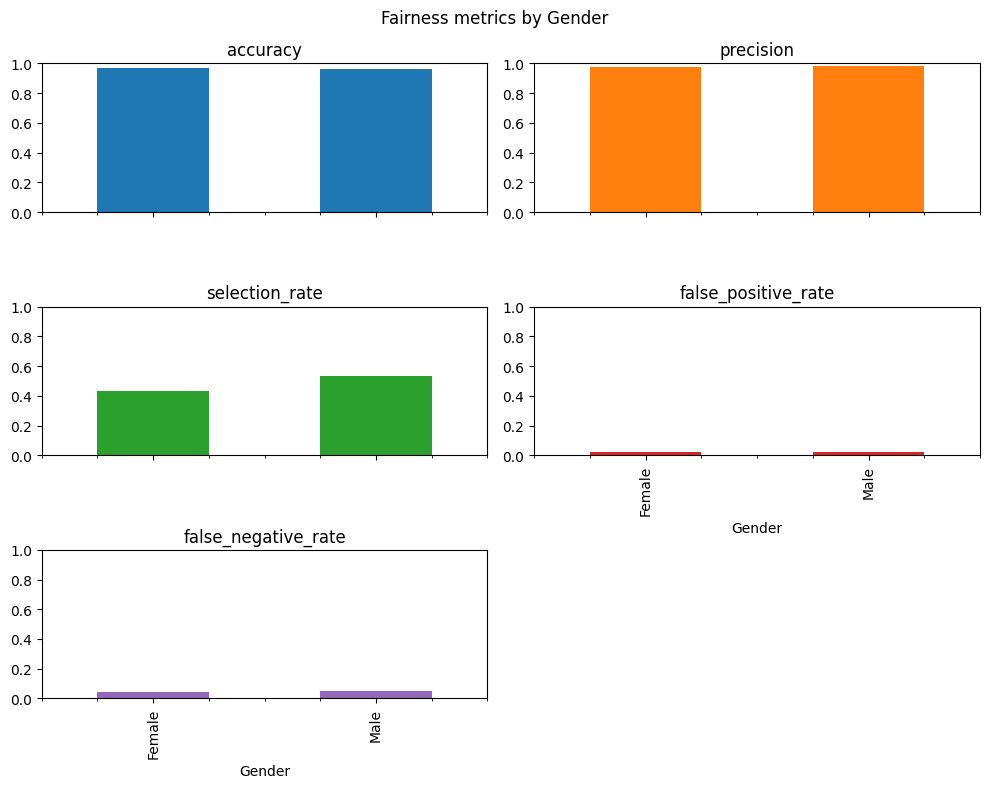

In [92]:
mf.by_group.plot.bar(
    subplots=True,
    layout=[3, 2],
    legend=False,
    figsize=(10, 8),
    ylim=[0, 1],
    title="Fairness metrics by Gender"
)
plt.tight_layout()
plt.show()

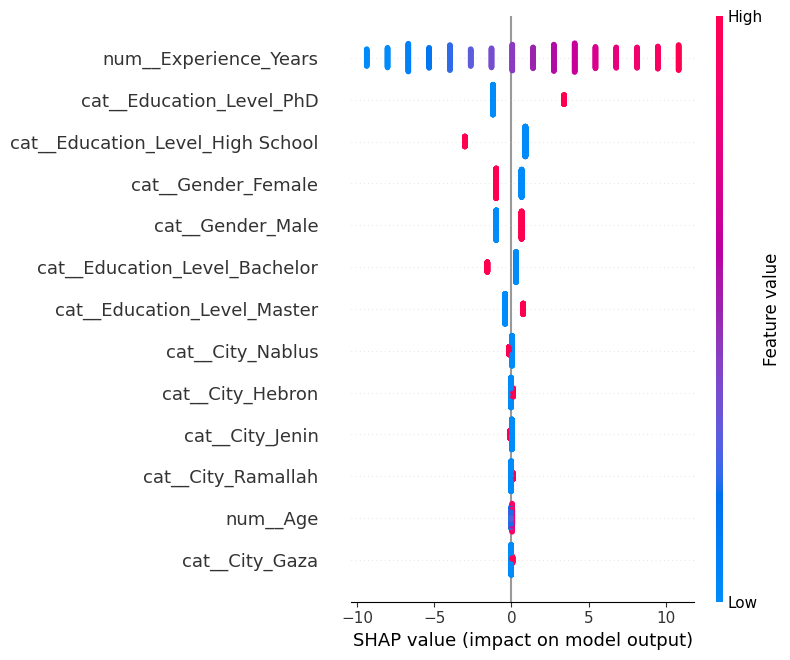

In [94]:
# Get preprocessed training data
X_train_proc = log_reg.named_steps["preprocess"].transform(X_train)
clf = log_reg.named_steps["clf"]

explainer = shap.LinearExplainer(clf, X_train_proc)
shap_values = explainer.shap_values(X_train_proc)

# Global summary
shap.summary_plot(shap_values, X_train_proc, feature_names=log_reg.named_steps["preprocess"].get_feature_names_out())

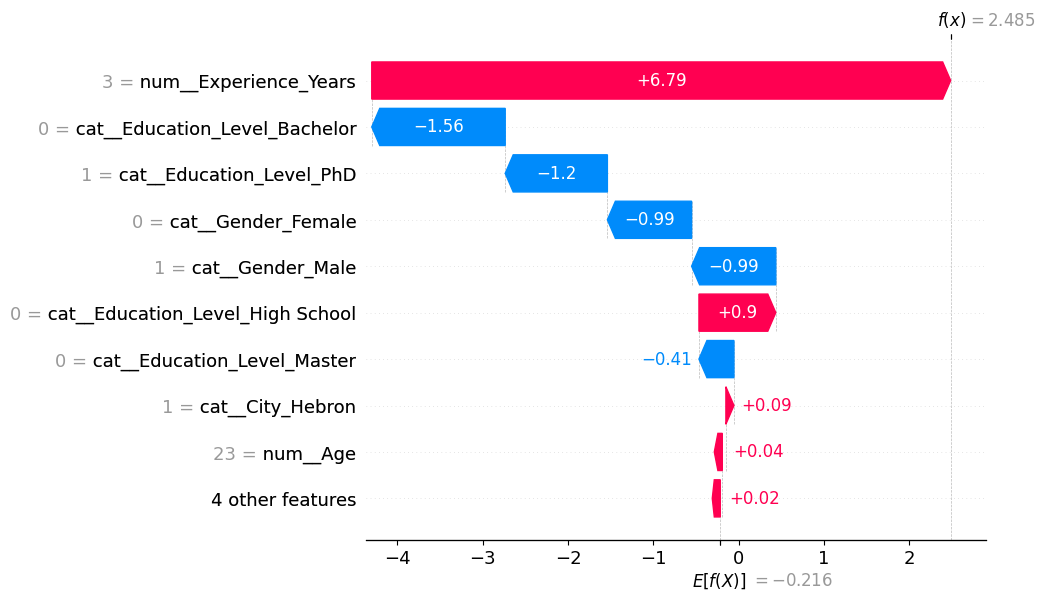

In [95]:
X_test_proc = log_reg.named_steps["preprocess"].transform(X_test)

i = 0  # index of instance
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_proc[i],
        feature_names=log_reg.named_steps["preprocess"].get_feature_names_out()
    )
)

In [97]:
X_train_np = X_train_proc  # already numeric
feature_names = log_reg.named_steps["preprocess"].get_feature_names_out()
class_names = ["low_salary", "high_salary"]

lime_explainer = LimeTabularExplainer(
    X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True
)

def predict_fn(x):
    return clf.predict_proba(x)

exp = lime_explainer.explain_instance(
    X_test_proc[i],
    predict_fn,
    num_features=10
)

exp.show_in_notebook()  # or exp.as_list() for text output

Salary distribution is vast ranging from 3000 to 20 000 with the median at 11 000é 12 000 quick look shows years experience is closer tied to salary

The male employees are over represented in the in the highest salary and women thend to show up more in the lower range

education level can affect salary as well but not as strongly as experience. Controling for education men are still over represented

Age not as important as experience when it comes to the model

Males likely to higher selection rate while women will have lower and males produced more false positives so the model is overestimating men having higher salaries

Women have lower True positives meaning the model missed

Historical Gender bias is in play

SHAP shows experience is the top feature and education is second and city third most in prediciting salary but it pushes for man more

LIME High slary men tend to be affected by being doctors and the city they live in. City and gender tends to push women down